In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, datetime

In [78]:
df_raw = pd.read_csv('raw_data.csv')
df_cleaned = pd.read_csv('clean_data.csv')
df_hist_prop = pd.read_csv('propaganda1.csv')
df_prop = pd.read_csv('propaganda2.csv')
df_llm_prop = pd.read_csv('propaganda_llm.csv')
df_ner = pd.read_csv('ner.csv')

In [3]:
df_cleaned = df_cleaned[df_cleaned['poster']=='@realDonaldTrump']

In [4]:
import re

URL_PATTERN = r"\b(?:https?://|www\.)[^\s<>\']+"

In [5]:
def assign_type(row):
    if row['poster'] != "@realDonaldTrump":
        return 'repost'
    if pd.isnull(row['text']):
        return "image_or_video"
    text =  re.sub(URL_PATTERN, "", row['text']).strip()
    if text == "":
        return 'url'
    return 'text_post'

In [79]:
start_date = "2025-01-20"
end_date = "2026-01-19"
df_raw = df_raw[df_raw['date'] <= end_date]
df_raw = df_raw[df_raw['date'] >= start_date]
df_raw['type'] = df_raw.apply(assign_type, axis=1)

In [7]:
df_raw

,id,date,time,poster,text,type
1077,115924288252880571,2026-01-19,18:11,@realDonaldTrump,NaN,image_or_video
1078,115924282126782262,2026-01-19,18:09,@realDonaldTrump,Trump Off to Strong Start in 2026 on “Affordab...,text_post
1079,115924279332406120,2026-01-19,18:08,@realDonaldTrump,Mortgage rates just fell below 6% for the firs...,text_post
1080,115924277763800167,2026-01-19,18:08,@realDonaldTrump,Trump administration ends temporary protected ...,text_post
1081,115924046475418008,2026-01-19,17:09,@realDonaldTrump,AMERICA IS BACK!!!,text_post
...,...,...,...,...,...,...
7955,113864112559510448,2025-01-20,22:01,@TeamTrump,🚨 President Trump signs an order to ease the p...,repost
7956,113864118604083125,2025-01-20,22:02,@TeamTrump,🚨 President Trump withdraws the United States ...,repost
7957,113864127240286673,2025-01-20,22:04,@TeamTrump,"Thanks to President Trump, American women are ...",repost
7958,113864692804149616,2025-01-21,00:28,@realDonaldTrump,Our first day in the White House is not over y...,text_post


In [80]:
df_raw.groupby('type')['id'].nunique().reset_index()

,type,id
0,image_or_video,1862
1,repost,172
2,text_post,3257
3,url,1158


In [9]:
df_raw['week'] = df_raw['date'].apply(lambda x: date.fromisoformat(x).strftime("%G-W%V"))
df_raw['hour'] = df_raw['time'].apply(lambda x: x.split(":")[0])
df_raw

,id,date,time,poster,text,type,week,hour
1077,115924288252880571,2026-01-19,18:11,@realDonaldTrump,NaN,image_or_video,2026-W04,18
1078,115924282126782262,2026-01-19,18:09,@realDonaldTrump,Trump Off to Strong Start in 2026 on “Affordab...,text_post,2026-W04,18
1079,115924279332406120,2026-01-19,18:08,@realDonaldTrump,Mortgage rates just fell below 6% for the firs...,text_post,2026-W04,18
1080,115924277763800167,2026-01-19,18:08,@realDonaldTrump,Trump administration ends temporary protected ...,text_post,2026-W04,18
1081,115924046475418008,2026-01-19,17:09,@realDonaldTrump,AMERICA IS BACK!!!,text_post,2026-W04,17
...,...,...,...,...,...,...,...,...
7955,113864112559510448,2025-01-20,22:01,@TeamTrump,🚨 President Trump signs an order to ease the p...,repost,2025-W04,22
7956,113864118604083125,2025-01-20,22:02,@TeamTrump,🚨 President Trump withdraws the United States ...,repost,2025-W04,22
7957,113864127240286673,2025-01-20,22:04,@TeamTrump,"Thanks to President Trump, American women are ...",repost,2025-W04,22
7958,113864692804149616,2025-01-21,00:28,@realDonaldTrump,Our first day in the White House is not over y...,text_post,2025-W04,00


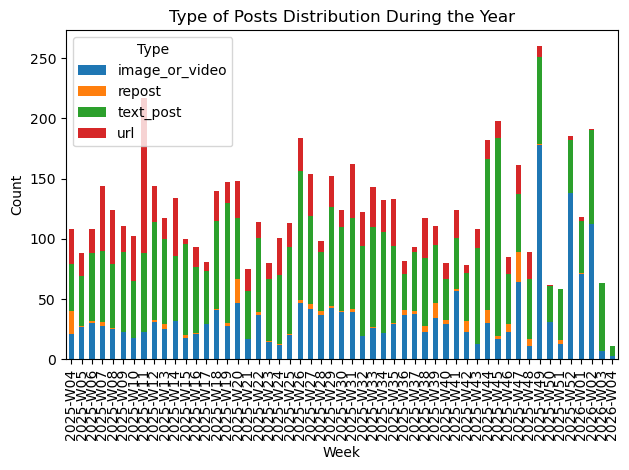

In [10]:
weekly = df_raw.groupby(['type', 'week'])['id'].nunique().reset_index().rename(columns={'id': 'count'})
weekly = weekly.pivot(index='week', columns='type', values='count')

weekly.plot(kind='bar', stacked=True)

plt.xlabel('Week')
plt.ylabel('Count')
plt.title('Type of Posts Distribution During the Year')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

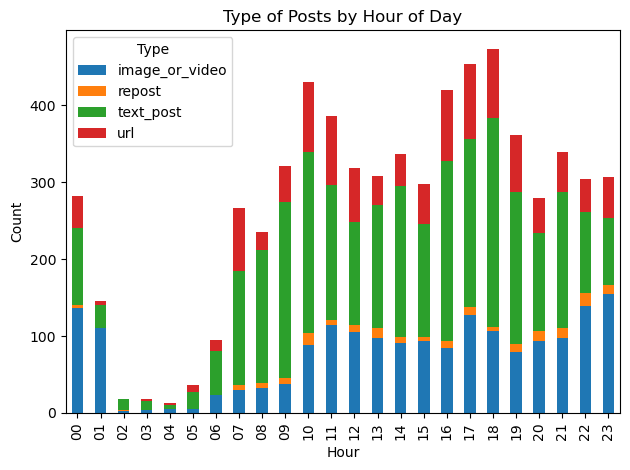

In [11]:
hourly = df_raw.groupby(['type', 'hour'])['id'].nunique().reset_index().rename(columns={'id': 'count'})
hourly = hourly.pivot(index='hour', columns='type', values='count')

hourly.plot(kind='bar', stacked=True)

plt.xlabel('Hour')
plt.ylabel('Count')
plt.title('Type of Posts by Hour of Day')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

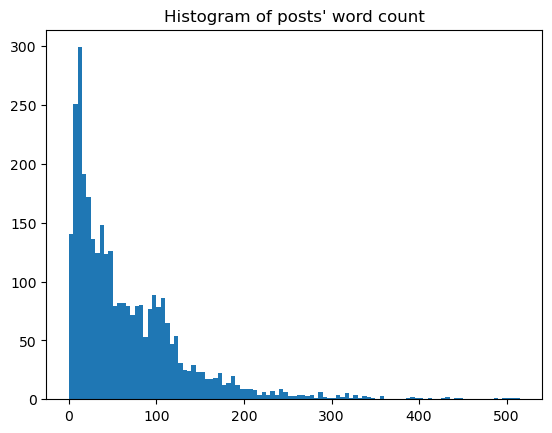

In [12]:
plt.hist(df_cleaned['word_count'], bins=range(0, max(df_cleaned['word_count']) + 5, 5))
plt.title("Histogram of posts' word count")
plt.show()

In [57]:
df_llm_prop['propaganda'].unique()

array(['No', 'Call', 'Attack on reputation', 'Distraction', '"Call"',
       'Justification', '"Attack on reputation"', 'Manipulative wording',
       'Simplification', '"Distraction"', '"Flag Waving"', '"No"',
       '["Justification"]'], dtype=object)

In [58]:
df_llm_prop['propaganda'] = df_llm_prop['propaganda'].apply(
    lambda x: x.replace('"', "").replace('[', "").replace(']', "")
).replace('Flag Waving', 'Justification')
df_llm_prop['propaganda'].unique()

array(['No', 'Call', 'Attack on reputation', 'Distraction',
       'Justification', 'Manipulative wording', 'Simplification'],
      dtype=object)

In [59]:
df_llm_prop['his_propaganda'].unique()
df_llm_prop['his_propaganda'] = df_llm_prop['his_propaganda'].apply(
    lambda x: x.replace('"', "").replace('[', "").replace(']', "")
)
df_llm_prop['his_propaganda'].unique()

array(['No', 'Geopolitical Framing', 'Victim Blaming', 'Genocide Denial'],
      dtype=object)

In [60]:
def is_propaganda(row):
    if row['his_propaganda'] == 'No' and row['propaganda'] == 'No':
        return False
    return True

df_llm_prop['is_propaganda'] = df_llm_prop.apply(is_propaganda, axis=1)

In [61]:
df_llm_prop['id'].nunique()

3403

In [62]:
id_list = df_cleaned['id']

In [71]:
df_llm_prop = df_llm_prop[df_llm_prop['id'].isin(id_list)]
df_hist_prop = df_hist_prop[df_hist_prop['id'].isin(id_list)]
df_prop = df_prop[df_prop['id'].isin(id_list)]

In [72]:
df_llm_prop.groupby('is_propaganda')['id'].count().reset_index()

,is_propaganda,id
0,False,608
1,True,2795


In [73]:
df_llm_prop.groupby('propaganda')['id'].count().reset_index().sort_values('id', ascending=False)

,propaganda,id
1,Call,1700
5,No,611
0,Attack on reputation,513
2,Distraction,305
3,Justification,225
6,Simplification,42
4,Manipulative wording,7


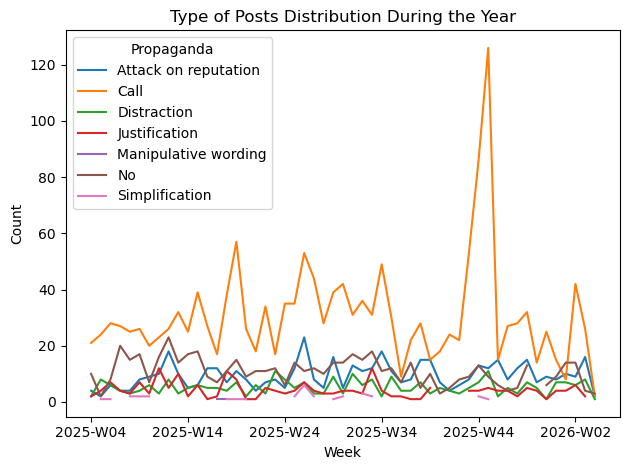

In [29]:
weekly = df_cleaned.merge(df_llm_prop)
weekly['week'] = weekly['date'].apply(lambda x: date.fromisoformat(x).strftime("%G-W%V"))
weekly = weekly.groupby(['propaganda', 'week'])['id'].nunique().reset_index().rename(columns={'id': 'count'})
weekly = weekly.pivot(index='week', columns='propaganda', values='count')

weekly.plot()

plt.xlabel('Week')
plt.ylabel('Count')
plt.title('Type of Posts Distribution During the Year')
plt.legend(title='Propaganda')
plt.tight_layout()
plt.show()

In [76]:
df_llm_prop.groupby('his_propaganda')['id'].nunique().reset_index().sort_values('id', ascending=False)

,his_propaganda,id
2,No,3373
1,Geopolitical Framing,28
0,Genocide Denial,1
3,Victim Blaming,1


In [61]:
his_prop_id = df_llm_prop[df_llm_prop['his_propaganda']!='No']['id']
list(df_cleaned[df_cleaned['id'].isin(his_prop_id)]['text'])

['A GREAT NEW BOOK, by NumberOne Bestselling Author, Peter Schweizer, The Invisible Coup: How American Elites and Foreign Powers Use Immigration as a Weapon, is out Tuesday. It is both vitally important and very interesting. Bad things have been happening to the U.S.A., and we must stop it, NOW! We will not let anyone bring down the American Empire. BUY THIS BOOK! Thank you for your attention to this matter!!! President DJT',
 'We have subsidized Denmark, and all of the Countries of the European Union, and others, for many years by not charging them Tariffs, or any other forms of remuneration. Now, after Centuries, it is time for Denmark to give back World Peace is at stake! China and Russia want Greenland, and there is not a thing that Denmark can do about it. They currently have two dogsleds as protection, one added recently. Only the United States of America, under PRESIDENT DONALD J. TRUMP, can play in this game, and very successfully, at that! Nobody will touch this sacred piece o

In [63]:
df = df_ner[df_ner['id'].isin(his_prop_id)]
df = df[df['type']=='LOC']

In [70]:
df.groupby('name')['id'].count().reset_index().sort_values('id', ascending=False).head(15)

,name,id
60,United States,14
26,Iran,12
67,World,8
10,China,8
27,Israel,7
58,Ukraine,6
15,Denmark,6
61,United States of America,5
38,Russia,5
4,America,5


In [47]:
df_prop

,id,label,score
0,115924282126782262,NO_PROPAGANDA,0.999599
1,115924279332406120,NO_PROPAGANDA,0.999583
2,115924277763800167,NO_PROPAGANDA,0.999530
3,115924043199702065,NO_PROPAGANDA,0.998822
4,115924025571521310,PROPAGANDA,0.998387
...,...,...,...
4626,113864112559510448,PROPAGANDA,0.521686
4627,113864118604083125,NO_PROPAGANDA,0.999318
4628,113864127240286673,PROPAGANDA,0.727259
4629,113864692804149616,NO_PROPAGANDA,0.932981


In [48]:
df_prop['label'] = df_prop['label'].map({'NO_PROPAGANDA': False, 'PROPAGANDA': True})
df_hist_prop['label'] = df_hist_prop['label'].map({'NO_PROPAGANDA': False, 'PROPAGANDA': True})

df_prop = df_prop.groupby('id')['label'].any().reset_index().rename(columns={'label': 'manipulation'})
df_hist_prop = df_hist_prop.groupby('id')['label'].any().reset_index().rename(columns={'label': 'historical_propaganda'})

In [49]:
df_prop = df_prop.merge(df_hist_prop)

In [74]:
df_prop.groupby(['manipulation', 'historical_propaganda'])['id'].count().reset_index()

,manipulation,historical_propaganda,id
0,False,False,382
1,False,True,581
2,True,True,2236


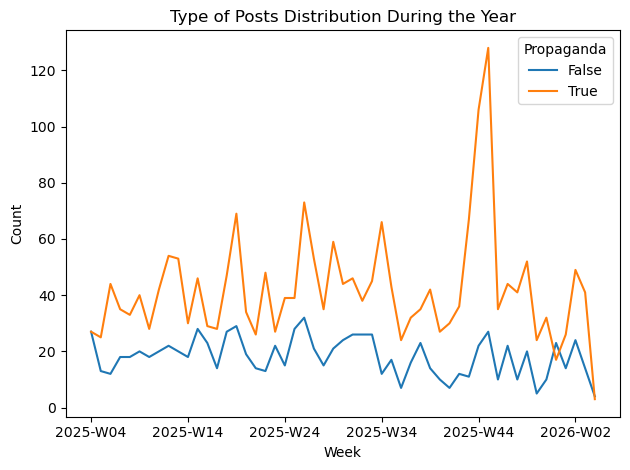

In [69]:
weekly = df_cleaned.merge(df_prop)
weekly['week'] = weekly['date'].apply(lambda x: date.fromisoformat(x).strftime("%G-W%V"))
weekly = weekly.groupby(['manipulation', 'week'])['id'].nunique().reset_index().rename(columns={'id': 'count'})
weekly = weekly.pivot(index='week', columns='manipulation', values='count')

weekly.plot()

plt.xlabel('Week')
plt.ylabel('Count')
plt.title('Type of Posts Distribution During the Year')
plt.legend(title='Propaganda')
plt.tight_layout()
plt.show()

In [66]:
df_comp = df_hist_prop.merge(df_llm_prop)

In [67]:
df_comp.groupby(['historical_propaganda', 'propaganda'])['id'].count().reset_index()

,historical_propaganda,propaganda,id
0,False,Attack on reputation,6
1,False,Call,158
2,False,Distraction,21
3,False,Justification,15
4,False,No,175
5,False,Simplification,7
6,True,Attack on reputation,502
7,True,Call,1425
8,True,Distraction,279
9,True,Justification,210


In [68]:
df_comp['manipulation'] = df_comp['propaganda'].apply(lambda x: False if x == "No" else True)
df_comp.groupby(['historical_propaganda', 'manipulation'])['id'].count().reset_index()

,historical_propaganda,manipulation,id
0,False,False,175
1,False,True,207
2,True,False,360
3,True,True,2457
